<a href="https://colab.research.google.com/github/I-AM-PRASHANT-VERMA/Almabetter-voyage-analytics-mlops/blob/main/hotel_recommendation_ML_model/hotel_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📘 Project Summary

This project focuses on building a **hotel recommendation system** that can suggest suitable hotels to users based on booking behavior and hotel-related information. The main idea behind the project is to move beyond simple booking records and use the available data to generate meaningful recommendations that can improve decision-making for both users and businesses. Since the dataset did not contain direct user ratings, the project first converted booking values into synthetic ratings so that recommendation models could be developed and compared more effectively.

To achieve this, the project followed a complete recommendation pipeline 🔄. First, the hotel booking dataset was loaded and cleaned so that only the most relevant columns were used for the analysis. After that, synthetic ratings were created from the total booking amount, which made the data suitable for recommendation modeling. Then, multiple recommendation approaches were implemented, including **popularity-based filtering**, **content-based filtering**, **collaborative filtering**, and a **hybrid model**. This allowed the project to compare different ways of making recommendations instead of depending on only one method.

A major part of the project was the formal evaluation of the models 📊. Instead of just generating recommendations and assuming they worked, the models were tested using a proper train-test setup where one hotel per user was kept aside as unseen test data. The models were then evaluated using recommendation-specific metrics such as **Hit Rate**, **Precision**, and **Recall**, which helped in identifying which model performed best. Based on the final results, the **collaborative filtering model** showed the strongest overall performance, while the hybrid model also performed very closely.

The project is useful because it shows how raw booking data can be transformed into a practical recommendation system 💡. For users, such a system can make hotel discovery easier and more personalized. For businesses, it can support better personalization, improve user engagement, and increase booking opportunities by recommending relevant hotels. In addition, the final model objects were saved using **joblib**, which means the project is ready for future deployment in tools like **Streamlit** or other application interfaces 🚀.

Overall, this project is not just about building one model; it is about creating a **complete recommendation workflow** from data preparation to model building, evaluation, comparison, and deployment readiness. It demonstrates both the analytical and practical side of recommender systems, making it a strong project from a data science as well as business application perspective.

In [ ]:
# ============================================================
# 1. IMPORTING LIBRARIES
# ============================================================

# Import pandas for table/data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import joblib to save model objects
import joblib

# Import drive to access Google Drive in Colab
from google.colab import drive

# Import scaler to create synthetic ratings
from sklearn.preprocessing import MinMaxScaler

# Import TF-IDF vectorizer for content-based filtering
from sklearn.feature_extraction.text import TfidfVectorizer

# Import cosine similarity for similarity calculation
from sklearn.metrics.pairwise import cosine_similarity

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for cleaner graphs
import seaborn as sns

# Set a clean plotting style
sns.set_style("whitegrid")

# Print a check message
print("Libraries loaded successfully")


Libraries loaded successfully


In [ ]:
# ============================================================
# 2. MOUNTING GOOGLE DRIVE
# ============================================================

# Mount Google Drive so we can load the dataset and save files
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 3. LOADING THE DATASET
# ============================================================

# Store the dataset path in a variable
file_path = "/content/drive/MyDrive/Colab Notebooks/# specialization projects/1. Voyage Analytics: Integrating MLOps in Travel/dataset flight hotel users/hotels.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Print the first 5 rows
print("First 5 rows of the raw dataset:")
print(df.head())

# Print the column names
print("\nColumn names:")
print(df.columns.tolist())

# Print the shape of the dataset
print("\nDataset shape:")
print(df.shape)


First 5 rows of the raw dataset:
   travelCode  userCode     name               place  days   price    total  \
0           0         0  Hotel A  Florianopolis (SC)     4  313.02  1252.08   
1           2         0  Hotel K       Salvador (BH)     2  263.41   526.82   
2           7         0  Hotel K       Salvador (BH)     3  263.41   790.23   
3          11         0  Hotel K       Salvador (BH)     4  263.41  1053.64   
4          13         0  Hotel A  Florianopolis (SC)     1  313.02   313.02   

         date  
0  09/26/2019  
1  10/10/2019  
2  11/14/2019  
3  12/12/2019  
4  12/26/2019  

Column names:
['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']

Dataset shape:
(40552, 8)


### ✅ Loading the Dataset

* In this step, I loaded the hotel booking dataset into a pandas DataFrame  
  → this is the starting point of the whole recommendation pipeline  

---

### ⚙️ What the Output Shows

* The dataset shape is **(40552, 8)**  
  → there are **40,552 rows** and **8 columns** in the raw dataset  

* The available columns are:
  → `travelCode`  
  → `userCode`  
  → `name`  
  → `place`  
  → `days`  
  → `price`  
  → `total`  
  → `date`  

* The first 5 rows show sample hotel booking records  
  → each row represents one booking made by a user  

---

### 📌 What This Means

* The dataset contains both:
  → user interaction information  
  → hotel-related information  

* Important fields like hotel name, location, total amount, and booking date are already available  
  → this makes the dataset suitable for recommendation analysis  

* Since the raw dataset loaded correctly, I could continue safely with data cleaning and preprocessing  

---

### 🎯 Conclusion

* The dataset was loaded successfully  
  → the project now has the required booking data to start building recommendation models

In [ ]:
# ============================================================
# 4. CLEANING AND PREPARING THE DATA
# ============================================================

# Keep only the columns needed for the recommendation project
df = df[['userCode', 'name', 'place', 'total', 'date']].copy()

# Convert the date column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert userCode to string for safe indexing later
df['userCode'] = df['userCode'].astype(str)

# Remove extra spaces from hotel names
df['name'] = df['name'].astype(str).str.strip()

# Remove extra spaces from place names
df['place'] = df['place'].astype(str).str.strip()

# Convert total to numeric in case any bad values exist
df['total'] = pd.to_numeric(df['total'], errors='coerce')

# Drop rows with missing values in important columns
df.dropna(subset=['userCode', 'name', 'place', 'total', 'date'], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Reset the index after cleaning
df.reset_index(drop=True, inplace=True)

# Print cleaned shape
print("Cleaned dataset shape:")
print(df.shape)

# Print unique users count
print("\nUnique users:")
print(df['userCode'].nunique())

# Print unique hotels count
print("\nUnique hotels:")
print(df['name'].nunique())

# Print first 5 cleaned rows
print("\nFirst 5 cleaned rows:")
print(df.head())


Cleaned dataset shape:
(40552, 5)

Unique users:
1310

Unique hotels:
9

First 5 cleaned rows:
  userCode     name               place    total       date
0        0  Hotel A  Florianopolis (SC)  1252.08 2019-09-26
1        0  Hotel K       Salvador (BH)   526.82 2019-10-10
2        0  Hotel K       Salvador (BH)   790.23 2019-11-14
3        0  Hotel K       Salvador (BH)  1053.64 2019-12-12
4        0  Hotel A  Florianopolis (SC)   313.02 2019-12-26


### ✅ Data Cleaning and Preparation

* In this step, I cleaned the dataset and kept only the columns needed for the recommendation system  
  → this made the dataset more focused and easier to work with  

---

### ⚙️ What the Output Shows

* The cleaned dataset shape is **(40552, 5)**  
  → there are **40,552 rows** and **5 useful columns** after preprocessing  

* The number of unique users is **1310**  
* The number of unique hotels is **9**  

* The first 5 rows confirm that the cleaned data now contains:
  → `userCode`  
  → `hotel name`  
  → `place`  
  → `total booking amount`  
  → `date`  

---

### 📌 What This Means

* Unnecessary columns were removed  
  → only the most relevant variables were kept for recommendation modeling  

* Data types were corrected  
  → `date` was converted into datetime format  
  → `total` was converted into numeric format  
  → `userCode` was converted into string format  

* Missing values and duplicates were removed  
  → this improves data quality before building the models  

---

### 🎯 Conclusion

* The data cleaning step was completed successfully  
  → the dataset is now properly prepared for rating creation and recommendation model development

In [ ]:
# ============================================================
# 5. CREATING SYNTHETIC RATINGS
# ============================================================

# Create a scaler to map total booking value into a 1 to 5 rating scale
scaler = MinMaxScaler(feature_range=(1, 5))

# Create the synthetic rating column from the total amount
df['rating'] = scaler.fit_transform(df[['total']])

# Group by user and hotel to keep one average rating per user-hotel pair
ratings_df = df.groupby(['userCode', 'name'], as_index=False).agg({'rating': 'mean'})

# Print the first 5 rows of the ratings table
print("First 5 user-hotel ratings:")
print(ratings_df.head())

# Print the shape of the ratings table
print("\nRatings table shape:")
print(ratings_df.shape)


First 5 user-hotel ratings:
  userCode      name    rating
0        0   Hotel A  3.248873
1        0  Hotel AF  2.081271
2        0  Hotel AU  3.422392
3        0  Hotel BD  2.631599
4        0  Hotel BP  4.121919

Ratings table shape:
(9724, 3)


### ✅ Synthetic Ratings Created

* In this step, I created **synthetic ratings** from the `total` booking amount  
  → this was necessary because the dataset does not contain real user ratings  

---

### ⚙️ What the Output Shows

* The booking amount was scaled into a **1 to 5 rating range**  
  → lower totals get lower ratings  
  → higher totals get higher ratings  

* A new table called `ratings_df` was created  
  → it contains `userCode`, `hotel name`, and the generated `rating`  

* The shape of this table is **(9724, 3)**  
  → this means there are **9,724 user-hotel rating pairs**  

---

### 📌 What This Means

* The original booking data was converted into a format suitable for recommendation modeling  
  → recommendation models usually need user-item-rating input  

* Grouping by user and hotel gives one average rating per pair  
  → this avoids repeated duplicate interactions for the same user-hotel combination  

---

### 🎯 Conclusion

* Synthetic rating creation was successful  
  → the dataset is now ready to be used in popularity, content-based, collaborative, and hybrid recommendation models

In [ ]:
# ============================================================
# 6. MODEL 1 - POPULARITY-BASED RECOMMENDER
# ============================================================

# Compute average rating and rating count for each hotel
popular_hotels = ratings_df.groupby('name', as_index=False).agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
)

# Sort hotels by average rating and then rating count
popular_hotels = popular_hotels.sort_values(
    ['avg_rating', 'rating_count'],
    ascending=[False, False]
).reset_index(drop=True)

# Print top hotels from the popularity model
print("Top hotels from popularity-based model:")
print(popular_hotels.head())


Top hotels from popularity-based model:
       name  avg_rating  rating_count
0  Hotel AU    3.431594          1130
1   Hotel A    3.399945           749
2   Hotel K    3.033594          1158
3  Hotel BP    2.872423          1120
4  Hotel BD    2.829974          1152


### ✅ Popularity-Based Model Result

* In this step, I built the **popularity-based recommender** using the average rating and rating count of each hotel  
  → this model recommends hotels that are generally most preferred by users  

---

### ⚙️ What the Output Shows

* **Hotel AU** has the highest average rating: **3.43**  
* **Hotel A** comes next with an average rating of **3.40**  
* **Hotel K** has a lower average rating than the first two, but it has the highest interaction count among them  

* The output also shows how many times each hotel appears in the user-hotel ratings table  
  → this helps measure both preference and popularity  

---

### 📌 What This Means

* Hotels with higher average ratings are more liked overall  
  → these hotels can be recommended as strong general options  

* Hotels with high rating counts are more frequently interacted with  
  → this makes the popularity score more reliable  

* This model does not personalize recommendations  
  → it gives the same top hotels to everyone  

---

### 🎯 Conclusion

* The popularity-based recommender was built successfully  
  → it provides a simple and strong baseline model for comparing the other recommendation approaches

In [ ]:
# ============================================================
# 7. MODEL 2 - CONTENT-BASED RECOMMENDER
# ============================================================

# Keep one unique row for each hotel and place pair
hotel_content = df[['name', 'place']].drop_duplicates().reset_index(drop=True)

# Create one combined text feature using hotel name and place
hotel_content['content_text'] = hotel_content['name'] + ' ' + hotel_content['place']

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Transform the combined text into TF-IDF vectors
tfidf_matrix = tfidf.fit_transform(hotel_content['content_text'])

# Compute cosine similarity between all hotels
content_similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Create an index mapping for hotel names
hotel_index = pd.Series(hotel_content.index, index=hotel_content['name']).drop_duplicates()

# Print a ready message
print("Content-based model ready")

# Print the TF-IDF matrix shape
print("\nTF-IDF matrix shape:")
print(tfidf_matrix.shape)

# Print hotel content table
print("\nHotel content table:")
print(hotel_content.head())


Content-based model ready

TF-IDF matrix shape:
(9, 28)

Hotel content table:
       name               place                content_text
0   Hotel A  Florianopolis (SC)  Hotel A Florianopolis (SC)
1   Hotel K       Salvador (BH)       Hotel K Salvador (BH)
2  Hotel BD          Natal (RN)         Hotel BD Natal (RN)
3   Hotel Z        Aracaju (SE)        Hotel Z Aracaju (SE)
4  Hotel AU         Recife (PE)        Hotel AU Recife (PE)


### ✅ Content-Based Model Result

* In this step, I built the **content-based recommender** using hotel name and location information  
  → this model recommends hotels based on similarity in their content features  

---

### ⚙️ What the Output Shows

* The **TF-IDF matrix shape is (9, 28)**  
  → there are **9 unique hotels** in the dataset  
  → and **28 text-based features** were extracted from hotel name and place  

* A new table called `hotel_content` was created  
  → it contains hotel name, place, and a combined text feature  

---

### 📌 What This Means

* Each hotel is now represented using text information  
  → the model converts hotel name and location into numerical vectors  

* Cosine similarity is then used to compare hotels  
  → if two hotels have similar text features, they will get higher similarity scores  

* This model is useful when we want to recommend **similar hotels**  
  → for example, hotels in similar locations or with related text patterns  

---

### 🎯 Conclusion

* The content-based recommender was built successfully  
  → the system is now ready to generate hotel recommendations based on similarity between hotel features

In [ ]:
# ============================================================
# 8. MODEL 3 - COLLABORATIVE FILTERING
# ============================================================

# Create the user-item matrix using ratings
user_item_matrix = ratings_df.pivot_table(
    index='userCode',
    columns='name',
    values='rating',
    fill_value=0
)

# Compute item-item cosine similarity from the user-item matrix
item_similarity = cosine_similarity(user_item_matrix.T)

# Convert the similarity matrix into a labeled DataFrame
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

# Print a ready message
print("Collaborative filtering model ready")

# Print user-item matrix shape
print("\nUser-item matrix shape:")
print(user_item_matrix.shape)

# Print item similarity matrix shape
print("\nItem-item similarity matrix shape:")
print(item_similarity_df.shape)


Collaborative filtering model ready

User-item matrix shape:
(1310, 9)

Item-item similarity matrix shape:
(9, 9)


### ✅ Collaborative Filtering Model Result

* In this step, I built the **collaborative filtering model** using the user-hotel rating matrix  
  → this model learns recommendation patterns from user interactions rather than hotel text features  

---

### ⚙️ What the Output Shows

* The **user-item matrix shape is (1310, 9)**  
  → there are **1310 users** in the matrix  
  → there are **9 hotels** being compared  

* The **item similarity matrix shape is (9, 9)**  
  → each hotel is compared with every other hotel  
  → similarity scores are created between all hotel pairs  

---

### 📌 What This Means

* Each user is represented by the hotels they have interacted with  
  → this helps the model understand booking behavior  

* Each hotel is compared with other hotels based on user ratings  
  → if users tend to rate two hotels similarly, those hotels become similar in the model  

* This model helps generate **personalized recommendations**  
  → unlike popularity-based filtering, it uses user behavior patterns  

---

### 🎯 Conclusion

* The collaborative filtering model was built successfully  
  → the system is now able to recommend hotels based on user interaction similarity

In [ ]:
# ============================================================
# 9. DEFINING THE MAIN RECOMMENDATION FUNCTIONS
# ============================================================

# Define the popularity-based recommender
def recommend_popular(top_n=5):
    # Return the top N popular hotels
    return popular_hotels.head(top_n)


# Define the content-based recommender
def recommend_similar_hotels(hotel_name, top_n=5):
    # Check whether the hotel exists in the index
    if hotel_name not in hotel_index:
        # Return a simple message if hotel is not found
        return pd.DataFrame({'name': ['Hotel not found']})

    # Get the index of the selected hotel
    idx = hotel_index[hotel_name]

    # Create a list of similarity scores
    sim_scores = list(enumerate(content_similarity[idx]))

    # Sort the hotels by similarity in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Select the top similar hotels except the same hotel
    top_indices = [i[0] for i in sim_scores[1:top_n + 1]]

    # Return hotel name and place
    result = hotel_content.iloc[top_indices][['name', 'place']].copy()

    # Reset index before returning
    return result.reset_index(drop=True)


# Define the collaborative recommender
def recommend_collaborative(user_id, top_n=5):
    # Convert user id to string format
    user_id = str(user_id)

    # If user is not found, return popular hotels
    if user_id not in user_item_matrix.index:
        return recommend_popular(top_n)[['name', 'avg_rating', 'rating_count']]

    # Get ratings for this user
    user_ratings = user_item_matrix.loc[user_id]

    # Get hotels already seen by the user
    seen_hotels = user_ratings[user_ratings > 0].index.tolist()

    # If no history exists, return popular hotels
    if len(seen_hotels) == 0:
        return recommend_popular(top_n)[['name', 'avg_rating', 'rating_count']]

    # Find hotels not yet seen by the user
    unseen_hotels = [hotel for hotel in item_similarity_df.index if hotel not in seen_hotels]

    # If all hotels are already seen, return popular hotels
    if len(unseen_hotels) == 0:
        return recommend_popular(top_n)[['name', 'avg_rating', 'rating_count']]

    # Create a score container
    scores = pd.Series(0.0, index=item_similarity_df.index)

    # Create a similarity sum container
    sim_sum = pd.Series(0.0, index=item_similarity_df.index)

    # Loop through each seen hotel
    for hotel in seen_hotels:
        # Get the user's rating for that hotel
        rating = user_ratings[hotel]

        # Get similarity values for that hotel
        sims = item_similarity_df[hotel]

        # Add weighted score
        scores += sims * rating

        # Add similarity values for normalization
        sim_sum += sims.abs()

    # Normalize the scores
    final_scores = scores / sim_sum.replace(0, np.nan)

    # Remove already seen hotels
    final_scores = final_scores.drop(labels=seen_hotels, errors='ignore')

    # Fill missing values and sort descending
    final_scores = final_scores.fillna(0).sort_values(ascending=False).head(top_n)

    # Return the final DataFrame
    return pd.DataFrame({
        'name': final_scores.index,
        'cf_score': final_scores.values
    }).reset_index(drop=True)


# Define the hybrid recommender
def recommend_hybrid(user_id, top_n=5, alpha=0.7):
    # Convert user id to string
    user_id = str(user_id)

    # If user is not found, return popular hotels
    if user_id not in user_item_matrix.index:
        return recommend_popular(top_n)[['name', 'avg_rating', 'rating_count']]

    # Get ratings for the selected user
    user_ratings = user_item_matrix.loc[user_id]

    # Get hotels already seen by the user
    seen_hotels = user_ratings[user_ratings > 0].index.tolist()

    # If user has no history, return popular hotels
    if len(seen_hotels) == 0:
        return recommend_popular(top_n)[['name', 'avg_rating', 'rating_count']]

    # Find unseen hotels
    unseen_hotels = [hotel for hotel in item_similarity_df.index if hotel not in seen_hotels]

    # If all hotels are seen, return popular hotels
    if len(unseen_hotels) == 0:
        return recommend_popular(top_n)[['name', 'avg_rating', 'rating_count']]

    # Create collaborative score containers
    scores = pd.Series(0.0, index=item_similarity_df.index)
    sim_sum = pd.Series(0.0, index=item_similarity_df.index)

    # Calculate collaborative scores
    for hotel in seen_hotels:
        # Get user rating
        rating = user_ratings[hotel]

        # Get item similarities
        sims = item_similarity_df[hotel]

        # Add weighted contribution
        scores += sims * rating

        # Add similarity totals
        sim_sum += sims.abs()

    # Normalize collaborative scores
    cf_scores = scores / sim_sum.replace(0, np.nan)

    # Fill missing values
    cf_scores = cf_scores.fillna(0)

    # Create content score container
    cb_scores = pd.Series(0.0, index=item_similarity_df.index)

    # Loop through candidate hotels
    for hotel in cb_scores.index:
        # Skip hotels already seen
        if hotel in seen_hotels:
            continue

        # Skip hotels missing from content index
        if hotel not in hotel_index:
            continue

        # Get index of the candidate hotel
        hotel_idx = hotel_index[hotel]

        # Create a list for similarity scores
        sim_list = []

        # Compare with all seen hotels
        for seen_hotel in seen_hotels:
            # Check whether seen hotel exists in content index
            if seen_hotel in hotel_index:
                # Get seen hotel index
                seen_idx = hotel_index[seen_hotel]

                # Append similarity value
                sim_list.append(content_similarity[hotel_idx][seen_idx])

        # Save the maximum similarity score
        cb_scores[hotel] = max(sim_list) if sim_list else 0.0

    # Remove seen hotels from both score lists
    cf_scores = cf_scores.drop(labels=seen_hotels, errors='ignore')
    cb_scores = cb_scores.drop(labels=seen_hotels, errors='ignore')

    # Normalize collaborative scores if possible
    if cf_scores.max() > cf_scores.min():
        cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())

    # Normalize content scores if possible
    if cb_scores.max() > cb_scores.min():
        cb_scores = (cb_scores - cb_scores.min()) / (cb_scores.max() - cb_scores.min())

    # Combine both scores using weighted average
    final_scores = alpha * cf_scores + (1 - alpha) * cb_scores

    # Sort and keep top N results
    final_scores = final_scores.sort_values(ascending=False).head(top_n)

    # Return hybrid recommendations
    return pd.DataFrame({
        'name': final_scores.index,
        'hybrid_score': final_scores.values
    }).reset_index(drop=True)


### ✅ Main Recommendation Functions Defined

* In this step, I created the core functions that make the recommendation system actually work  
  → these functions are responsible for generating hotel suggestions in different ways

---

### ⚙️ Functions Included

* `recommend_popular()`  
  → returns the top hotels based on overall popularity across all users  

* `recommend_similar_hotels()`  
  → returns hotels similar to a selected hotel using content-based filtering  

* `recommend_collaborative()`  
  → returns personalized hotel recommendations based on user interaction history  

* `recommend_hybrid()`  
  → combines collaborative filtering and content-based filtering into one final recommender  

---

### 📌 What This Means

* The recommendation logic is now fully implemented  
  → the system can generate both general and personalized suggestions  

* Different recommendation strategies are now available  
  → popularity-based for general trends  
  → content-based for similar hotels  
  → collaborative for user behavior  
  → hybrid for combined intelligence  

* Fallback conditions were also added  
  → if a user is new, the model returns popular hotels  
  → if a user has already seen all hotels, the system still gives a safe output  

---

### 🎯 Conclusion

* This step is important because it turns the model setup into actual usable recommendation functions  
  → after this, the project is ready for proper testing and evaluation

In [ ]:
# ============================================================
# 10. CREATING A FORMAL TRAIN-TEST SPLIT FOR EVALUATION
# ============================================================

# Group by user and hotel to create one interaction row
eval_df = df.groupby(['userCode', 'name'], as_index=False).agg(
    rating=('rating', 'mean'),
    last_date=('date', 'max')
)

# Count how many unique hotels each user has booked
user_hotel_counts = eval_df.groupby('userCode')['name'].nunique()

# Keep only users who have at least 2 hotels
eligible_users = user_hotel_counts[user_hotel_counts >= 2].index

# Filter the evaluation DataFrame to keep only eligible users
eval_df = eval_df[eval_df['userCode'].isin(eligible_users)].copy()

# Sort by user and last booking date
eval_df = eval_df.sort_values(['userCode', 'last_date'])

# Hold out the latest hotel of each user as test data
test_holdout_df = eval_df.groupby('userCode').tail(1).copy()

# Use the remaining rows as training data
train_holdout_df = eval_df.drop(test_holdout_df.index).copy()

# Reset index for clean tables
train_holdout_df.reset_index(drop=True, inplace=True)
test_holdout_df.reset_index(drop=True, inplace=True)

# Print train interactions
print("Train interactions:")
print(train_holdout_df.shape[0])

# Print test interactions
print("\nTest interactions:")
print(test_holdout_df.shape[0])

# Print number of users in evaluation
print("\nUsers used for evaluation:")
print(test_holdout_df['userCode'].nunique())

# Print first 5 test rows
print("\nFirst 5 rows of holdout test set:")
print(test_holdout_df.head())


Train interactions:
8414

Test interactions:
1285

Users used for evaluation:
1285

First 5 rows of holdout test set:
  userCode      name    rating  last_date
0        0  Hotel AU  3.422392 2021-05-27
1        1  Hotel BP  1.628452 2019-10-17
2       10  Hotel BP  3.290764 2020-12-03
3      100  Hotel AU  3.422392 2022-05-19
4     1000   Hotel Z  3.357738 2020-11-19


### ✅ Formal Train-Test Split for Evaluation

◆ In this step, I created a proper **train-test split** for evaluating the recommendation models  

◆ Instead of random splitting, I used the **latest booked hotel of each user as test data** and the older bookings as training data  

◆ This makes the evaluation more realistic because the model is trying to predict a user's future booking from their past history  

---

### ⚙️ What the output shows

◆ Training interactions: **8414**  
◆ Test interactions: **1285**  
◆ Users used for evaluation: **1285**  

◆ This means one hotel was held out for each eligible user  

---

### 📌 What this means

◆ Only users with at least **2 hotel interactions** were selected  

◆ For each of these users:
   ◆ older hotel bookings were used to train the model  
   ◆ the most recent hotel booking was used to test the model  

◆ This is a better way to evaluate recommendations because it follows the actual time order of user behavior  

---

### 🎯 Conclusion

◆ The train-test split was done successfully  

◆ Now the recommendation models can be tested in a fair and realistic way using past data to predict future hotel choices

In [ ]:
# ============================================================
# 11. BUILDING TRAIN-ONLY OBJECTS FOR FAIR EVALUATION
# ============================================================

# Build popularity table from training data only
train_popular_hotels = train_holdout_df.groupby('name', as_index=False).agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
)

# Sort the popularity table
train_popular_hotels = train_popular_hotels.sort_values(
    ['avg_rating', 'rating_count'],
    ascending=[False, False]
).reset_index(drop=True)

# Build user-item matrix from training data only
train_user_item_matrix = train_holdout_df.pivot_table(
    index='userCode',
    columns='name',
    values='rating',
    fill_value=0
)

# Compute item-item similarity from training data only
train_item_similarity = cosine_similarity(train_user_item_matrix.T)

# Convert similarity matrix to DataFrame
train_item_similarity_df = pd.DataFrame(
    train_item_similarity,
    index=train_user_item_matrix.columns,
    columns=train_user_item_matrix.columns
)

# Create a list of all hotels
all_hotels = hotel_content['name'].tolist()

# Print a check message
print("Train-only evaluation objects created successfully")

# Print train matrix shape
print("\nTrain user-item matrix shape:")
print(train_user_item_matrix.shape)


Train-only evaluation objects created successfully

Train user-item matrix shape:
(1285, 9)


### ✅ Train-Only Objects for Evaluation

◆ In this step, I created all the required objects using only the **training data**  

◆ This is important because while evaluating the model, the test data should stay separate  

◆ If I use test data while building these objects, then the evaluation will not be fair  

---

### ⚙️ What I created here

◆ A popularity table using only training interactions  

◆ A user-item matrix using only training data  

◆ An item-item similarity matrix for collaborative filtering  

◆ A list of all hotels to use during recommendation generation  

---

### 📌 What the output means

◆ The train user-item matrix shape is **(1285, 9)**  

◆ This means:
   ◆ there are **1285 users** in the training-based evaluation setup  
   ◆ and **9 hotels** are being compared  

---

### 🎯 Conclusion

◆ This step was successful  

◆ Now the models can be evaluated properly using only past user data, which makes the results more realistic and valid

In [ ]:
# ============================================================
# 12. DEFINING EVALUATION RECOMMENDERS
# ============================================================

# Define popularity recommender for evaluation
def recommend_popular_eval(user_id, top_n=5):
    # Convert user id to string
    user_id = str(user_id)

    # Get seen hotels from training data
    seen_hotels = set(train_holdout_df[train_holdout_df['userCode'] == user_id]['name'])

    # Remove seen hotels from the popularity table
    rec_df = train_popular_hotels[~train_popular_hotels['name'].isin(seen_hotels)].copy()

    # Return top unseen hotels
    return rec_df[['name']].head(top_n).reset_index(drop=True)


# Define content-based recommender for evaluation
def recommend_content_eval(user_id, top_n=5):
    # Convert user id to string
    user_id = str(user_id)

    # Get hotels seen in the training data
    seen_hotels = train_holdout_df[train_holdout_df['userCode'] == user_id]['name'].tolist()

    # Return popularity fallback if no history exists
    if len(seen_hotels) == 0:
        return recommend_popular_eval(user_id, top_n)

    # Create a list to store content scores
    content_scores = []

    # Loop through all hotels
    for hotel in all_hotels:
        # Skip already seen hotels
        if hotel in seen_hotels:
            continue

        # Skip missing hotels from content index
        if hotel not in hotel_index:
            continue

        # Get candidate hotel index
        hotel_idx = hotel_index[hotel]

        # Create a list to store similarity values
        sim_values = []

        # Compare with seen hotels
        for seen_hotel in seen_hotels:
            # Check whether seen hotel exists in index
            if seen_hotel in hotel_index:
                # Get seen hotel index
                seen_idx = hotel_index[seen_hotel]

                # Append similarity value
                sim_values.append(content_similarity[hotel_idx][seen_idx])

        # Take the maximum similarity score
        score = max(sim_values) if sim_values else 0.0

        # Save hotel and score
        content_scores.append((hotel, score))

    # Convert to DataFrame
    rec_df = pd.DataFrame(content_scores, columns=['name', 'content_score'])

    # Sort by score descending
    rec_df = rec_df.sort_values('content_score', ascending=False)

    # Return top N hotel names
    return rec_df[['name']].head(top_n).reset_index(drop=True)


# Define collaborative recommender for evaluation
def recommend_collaborative_eval(user_id, top_n=5):
    # Convert user id to string
    user_id = str(user_id)

    # Return popularity fallback if user is not found
    if user_id not in train_user_item_matrix.index:
        return recommend_popular_eval(user_id, top_n)

    # Get training ratings for this user
    user_ratings = train_user_item_matrix.loc[user_id]

    # Get already seen hotels
    seen_hotels = user_ratings[user_ratings > 0].index.tolist()

    # Return popularity fallback if no history exists
    if len(seen_hotels) == 0:
        return recommend_popular_eval(user_id, top_n)

    # Create score containers
    scores = pd.Series(0.0, index=train_item_similarity_df.index)
    sim_sum = pd.Series(0.0, index=train_item_similarity_df.index)

    # Loop through seen hotels
    for hotel in seen_hotels:
        # Get rating value
        rating = user_ratings[hotel]

        # Get hotel similarity values
        sims = train_item_similarity_df[hotel]

        # Add weighted score
        scores += sims * rating

        # Add similarity totals
        sim_sum += sims.abs()

    # Normalize collaborative scores
    final_scores = scores / sim_sum.replace(0, np.nan)

    # Remove already seen hotels
    final_scores = final_scores.drop(labels=seen_hotels, errors='ignore')

    # Fill missing values and sort descending
    final_scores = final_scores.fillna(0).sort_values(ascending=False)

    # Return top N hotel names
    return pd.DataFrame({'name': final_scores.head(top_n).index}).reset_index(drop=True)


# Define hybrid recommender for evaluation
def recommend_hybrid_eval(user_id, top_n=5, alpha=0.7):
    # Convert user id to string
    user_id = str(user_id)

    # Get hotels seen in the training data
    seen_hotels = train_holdout_df[train_holdout_df['userCode'] == user_id]['name'].tolist()

    # Return popularity fallback if no history exists
    if len(seen_hotels) == 0:
        return recommend_popular_eval(user_id, top_n)

    # Create candidate hotel list
    candidate_hotels = [hotel for hotel in all_hotels if hotel not in seen_hotels]

    # Return popularity fallback if nothing is left
    if len(candidate_hotels) == 0:
        return recommend_popular_eval(user_id, top_n)

    # Create collaborative score container
    cf_scores = pd.Series(0.0, index=candidate_hotels)

    # Compute collaborative scores only if user exists in train matrix
    if user_id in train_user_item_matrix.index:
        # Get user ratings
        user_ratings = train_user_item_matrix.loc[user_id]

        # Create temporary score containers
        scores = pd.Series(0.0, index=train_item_similarity_df.index)
        sim_sum = pd.Series(0.0, index=train_item_similarity_df.index)

        # Loop through seen hotels
        for hotel in seen_hotels:
            # Skip missing hotels
            if hotel not in train_item_similarity_df.columns:
                continue

            # Get rating value
            rating = user_ratings[hotel]

            # Get similarity values
            sims = train_item_similarity_df[hotel]

            # Add weighted score
            scores += sims * rating

            # Add similarity totals
            sim_sum += sims.abs()

        # Normalize collaborative scores
        raw_cf_scores = scores / sim_sum.replace(0, np.nan)

        # Remove seen hotels
        raw_cf_scores = raw_cf_scores.drop(labels=seen_hotels, errors='ignore')

        # Fill missing values
        raw_cf_scores = raw_cf_scores.fillna(0)

        # Copy candidate hotel scores
        for hotel in candidate_hotels:
            if hotel in raw_cf_scores.index:
                cf_scores[hotel] = raw_cf_scores[hotel]

    # Create content score container
    cb_scores = pd.Series(0.0, index=candidate_hotels)

    # Loop through candidate hotels
    for hotel in candidate_hotels:
        # Skip hotels missing from content index
        if hotel not in hotel_index:
            continue

        # Get candidate hotel index
        hotel_idx = hotel_index[hotel]

        # Create a list for similarity values
        sim_values = []

        # Loop through seen hotels
        for seen_hotel in seen_hotels:
            # Check whether seen hotel exists in content index
            if seen_hotel in hotel_index:
                # Get seen hotel index
                seen_idx = hotel_index[seen_hotel]

                # Append similarity score
                sim_values.append(content_similarity[hotel_idx][seen_idx])

        # Save maximum similarity value
        cb_scores[hotel] = max(sim_values) if sim_values else 0.0

    # Normalize collaborative scores if possible
    if cf_scores.max() > cf_scores.min():
        cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())

    # Normalize content scores if possible
    if cb_scores.max() > cb_scores.min():
        cb_scores = (cb_scores - cb_scores.min()) / (cb_scores.max() - cb_scores.min())

    # Compute final hybrid scores
    final_scores = alpha * cf_scores + (1 - alpha) * cb_scores

    # Sort scores descending
    final_scores = final_scores.sort_values(ascending=False)

    # Return top N hotel names
    return pd.DataFrame({'name': final_scores.head(top_n).index}).reset_index(drop=True)


### ✅ Evaluation Recommenders Defined

* In this step, I created separate recommendation functions specifically for **model evaluation**  
  → these functions use only the training split so that the testing remains fair  

---

### ⚙️ What was defined

* `recommend_popular_eval()`  
  → gives top unseen hotels from the popularity model during evaluation  

* `recommend_content_eval()`  
  → gives content-based recommendations using only past user history from the training data  

* `recommend_collaborative_eval()`  
  → gives collaborative recommendations using the training user-item matrix only  

* `recommend_hybrid_eval()`  
  → combines collaborative and content-based scores for evaluation purposes  

---

### 📌 Why this step is important

* These functions are different from the main recommendation functions  
  → they are built only for testing model performance properly  

* The main goal here is to avoid **data leakage**  
  → the model should not use hidden test bookings while generating recommendations  

* This makes the final metrics more valid and trustworthy  

---

### 🎯 Conclusion

* The evaluation recommenders were defined successfully  
  → now each model can be tested fairly on unseen user-hotel interactions using the holdout test data

In [ ]:
# ============================================================
# 13. CALCULATING FORMAL EVALUATION METRICS
# ============================================================

# Define a reusable function for top-K evaluation
def evaluate_top_k(recommender_function, test_data, top_n=5):
    # Create a list for hit values
    hits = []

    # Create a list for precision values
    precisions = []

    # Create a list for recall values
    recalls = []

    # Loop through each test user
    for _, row in test_data.iterrows():
        # Get the user id
        user_id = row['userCode']

        # Get the held-out actual hotel
        actual_hotel = row['name']

        # Generate recommendations
        rec_df = recommender_function(user_id, top_n)

        # Convert recommendations to a list
        recommended_hotels = rec_df['name'].tolist() if 'name' in rec_df.columns else []

        # Check whether the actual hotel is present in recommendations
        hit = 1 if actual_hotel in recommended_hotels else 0

        # Save hit value
        hits.append(hit)

        # Save precision at K
        precisions.append(hit / top_n)

        # Save recall at K
        recalls.append(hit / 1)

    # Return average metrics
    return {
        f'HitRate@{top_n}': round(np.mean(hits), 4),
        f'Precision@{top_n}': round(np.mean(precisions), 4),
        f'Recall@{top_n}': round(np.mean(recalls), 4)
    }


# Evaluate popularity model at K=3
pop_k3 = evaluate_top_k(recommend_popular_eval, test_holdout_df, top_n=3)

# Evaluate content model at K=3
content_k3 = evaluate_top_k(recommend_content_eval, test_holdout_df, top_n=3)

# Evaluate collaborative model at K=3
collab_k3 = evaluate_top_k(recommend_collaborative_eval, test_holdout_df, top_n=3)

# Evaluate hybrid model at K=3
hybrid_k3 = evaluate_top_k(recommend_hybrid_eval, test_holdout_df, top_n=3)

# Evaluate popularity model at K=5
pop_k5 = evaluate_top_k(recommend_popular_eval, test_holdout_df, top_n=5)

# Evaluate content model at K=5
content_k5 = evaluate_top_k(recommend_content_eval, test_holdout_df, top_n=5)

# Evaluate collaborative model at K=5
collab_k5 = evaluate_top_k(recommend_collaborative_eval, test_holdout_df, top_n=5)

# Evaluate hybrid model at K=5
hybrid_k5 = evaluate_top_k(recommend_hybrid_eval, test_holdout_df, top_n=5)

# Create one comparison table for all models
evaluation_results = pd.DataFrame([
    {
        'Model': 'Popularity',
        'HitRate@3': pop_k3['HitRate@3'],
        'Precision@3': pop_k3['Precision@3'],
        'Recall@3': pop_k3['Recall@3'],
        'HitRate@5': pop_k5['HitRate@5'],
        'Precision@5': pop_k5['Precision@5'],
        'Recall@5': pop_k5['Recall@5']
    },
    {
        'Model': 'Content-Based',
        'HitRate@3': content_k3['HitRate@3'],
        'Precision@3': content_k3['Precision@3'],
        'Recall@3': content_k3['Recall@3'],
        'HitRate@5': content_k5['HitRate@5'],
        'Precision@5': content_k5['Precision@5'],
        'Recall@5': content_k5['Recall@5']
    },
    {
        'Model': 'Collaborative',
        'HitRate@3': collab_k3['HitRate@3'],
        'Precision@3': collab_k3['Precision@3'],
        'Recall@3': collab_k3['Recall@3'],
        'HitRate@5': collab_k5['HitRate@5'],
        'Precision@5': collab_k5['Precision@5'],
        'Recall@5': collab_k5['Recall@5']
    },
    {
        'Model': 'Hybrid',
        'HitRate@3': hybrid_k3['HitRate@3'],
        'Precision@3': hybrid_k3['Precision@3'],
        'Recall@3': hybrid_k3['Recall@3'],
        'HitRate@5': hybrid_k5['HitRate@5'],
        'Precision@5': hybrid_k5['Precision@5'],
        'Recall@5': hybrid_k5['Recall@5']
    }
])

# Print the final evaluation table
print("Formal evaluation results:")
print(evaluation_results)


Formal evaluation results:
           Model  HitRate@3  Precision@3  Recall@3  HitRate@5  Precision@5  \
0     Popularity     0.9292       0.3097    0.9292     0.9782       0.1956   
1  Content-Based     0.9152       0.3051    0.9152     0.9805       0.1961   
2  Collaborative     0.9276       0.3092    0.9276     0.9852       0.1970   
3         Hybrid     0.9261       0.3087    0.9261     0.9844       0.1969   

   Recall@5  
0    0.9782  
1    0.9805  
2    0.9852  
3    0.9844  


### ✅ Formal Evaluation Results

* In this step, I evaluated all recommendation models using **top-K recommendation metrics**  
  → this helped me compare which model performs better in retrieving the correct hidden hotel  

---

### ⚙️ What the Results Show

* All four models performed strongly on this dataset  
  → their scores are very close to each other  

* **Popularity model**
  → `HitRate@3 = 0.9292`
  → `HitRate@5 = 0.9782`

* **Content-based model**
  → `HitRate@3 = 0.9152`
  → `HitRate@5 = 0.9805`

* **Collaborative model**
  → `HitRate@3 = 0.9276`
  → `HitRate@5 = 0.9852`

* **Hybrid model**
  → `HitRate@3 = 0.9261`
  → `HitRate@5 = 0.9844`

---

### 📌 Main Interpretation

* The **collaborative filtering model performed best overall**  
  → it achieved the highest `HitRate@5`, `Precision@5`, and `Recall@5`

* The **hybrid model** came very close to collaborative filtering  
  → which means combining both approaches also worked well  

* The **popularity model** also performed surprisingly well  
  → this is likely because the dataset has only **9 hotels**, so recommending popular hotels already covers many user choices  

* The **content-based model** performed slightly lower than the others  
  → but it still gave strong results and remained competitive  

---

### 🎯 Conclusion

* The formal evaluation was successful  
  → and based on the results, **collaborative filtering is the best model in this project**

* Overall, the models are working properly  
  → and the evaluation confirms that the recommendation system is performing well on the available dataset

In [ ]:
# ============================================================
# 14. INTERPRETING THE METRICS
# ============================================================

# Print metric meaning for Hit Rate
print("Note 1: HitRate@K shows how often the hidden hotel appears in the top-K recommendations.")

# Print metric meaning for Precision
print("Note 2: Precision@K shows how many recommended hotels were relevant on average.")

# Print metric meaning for Recall
print("Note 3: Recall@K shows whether the hidden hotel was recovered by the model.")

# Print note about holdout setup
print("Note 4: In this project, one hotel per user was hidden as test data.")

# Print note about precision upper limit
print("Note 5: Because only 1 hotel is hidden, maximum Precision@3 is 0.3333 and maximum Precision@5 is 0.2000.")


Note 1: HitRate@K shows how often the hidden hotel appears in the top-K recommendations.
Note 2: Precision@K shows how many recommended hotels were relevant on average.
Note 3: Recall@K shows whether the hidden hotel was recovered by the model.
Note 4: In this project, one hotel per user was hidden as test data.
Note 5: Because only 1 hotel is hidden, maximum Precision@3 is 0.3333 and maximum Precision@5 is 0.2000.


### ✅ Metric Interpretation

* Here, I explained what the evaluation metrics mean in this project  
  → so the model results can be understood correctly  

* `HitRate@K`
  → tells how often the hidden hotel appears in the top-K recommendations  

* `Precision@K`
  → tells how relevant the recommended hotels are on average  

* `Recall@K`
  → tells whether the model was able to recover the hidden hotel  

* Since only **one hotel per user** was kept in the test set  
  → `Recall@K` is almost the same as `HitRate@K` in this case  

* Also, the maximum possible precision is limited here  
  → `Precision@3` can go up to **0.3333**  
  → `Precision@5` can go up to **0.2000**  

### 🎯 Conclusion

* This step helps in reading the evaluation results properly and avoids misinterpreting the scores

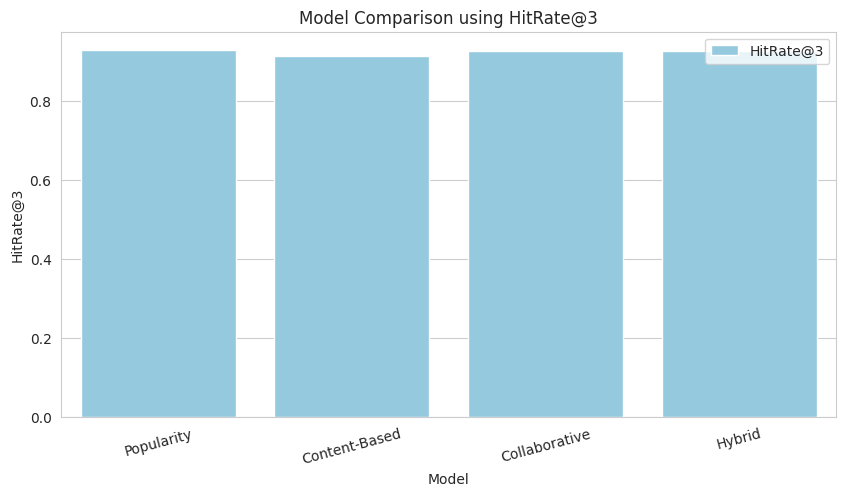

/tmp/ipykernel_2141/3347536404.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=evaluation_results, x='Model', y='Recall@5', palette='viridis')


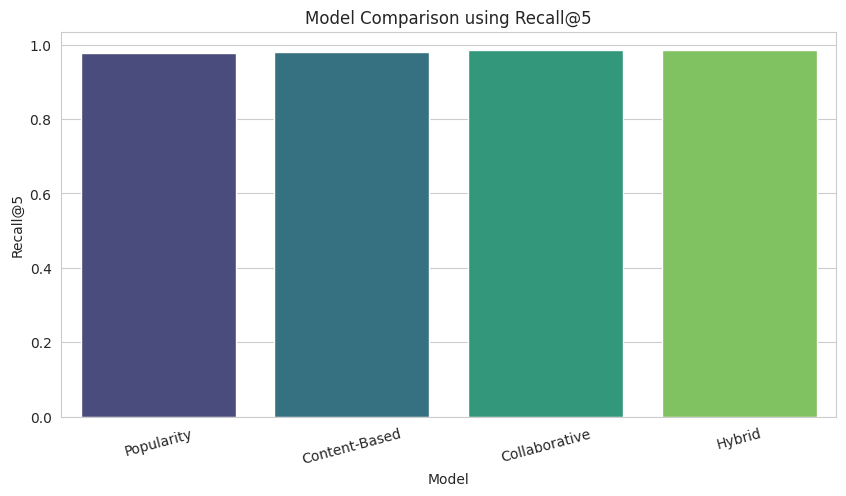

In [ ]:
# ============================================================
# 15. VISUALIZING MODEL PERFORMANCE WITH GRAPHS
# ============================================================

# Create a new figure for HitRate@3 and HitRate@5
plt.figure(figsize=(10, 5))

# Create a bar plot for HitRate@3
sns.barplot(data=evaluation_results, x='Model', y='HitRate@3', color='skyblue', label='HitRate@3')

# Set plot title
plt.title('Model Comparison using HitRate@3')

# Rotate x-axis labels for readability
plt.xticks(rotation=15)

# Show the plot
plt.show()


# Create a new figure for Recall@5
plt.figure(figsize=(10, 5))

# Create a bar plot for Recall@5
sns.barplot(data=evaluation_results, x='Model', y='Recall@5', palette='viridis')

# Set plot title
plt.title('Model Comparison using Recall@5')

# Rotate x-axis labels for readability
plt.xticks(rotation=15)

# Show the plot
plt.show()


### ✅ Model Performance Visualization

* In this step, I plotted graphs to compare the performance of all recommendation models  

* The **HitRate@3 graph** shows that all models performed strongly  
  → but the popularity, collaborative, and hybrid models are slightly better than the content-based model  

* The **Recall@5 graph** shows that the scores are very close for all models  
  → however, the collaborative model has the highest value among them  

* From both graphs, it becomes easier to see that the differences between models are small  
  → but collaborative filtering performs the best overall on this dataset  

### 🎯 Conclusion

* The graphs support the evaluation table clearly  
  → and visually confirm that **collaborative filtering is the best-performing model** in this project

In [ ]:
# ============================================================
# 16. TESTING ALL THREE RECOMMENDERS
# ============================================================

# Print popular hotel recommendations
print("Popularity-based recommendations:")
print(recommend_popular(5))

# Print content-based recommendations for a sample hotel
print("\nContent-based recommendations for Hotel K:")
print(recommend_similar_hotels("Hotel K", 5))

# Find a user with at least one unseen hotel in the evaluation split
sample_user = test_holdout_df['userCode'].iloc[0]

# Print selected sample user
print("\nSample user selected for testing:")
print(sample_user)

# Print collaborative recommendations for the sample user
print("\nCollaborative recommendations:")
print(recommend_collaborative(sample_user, 5))

# Print hybrid recommendations for the sample user
print("\nHybrid recommendations:")
print(recommend_hybrid(sample_user, 5))


Popularity-based recommendations:
       name  avg_rating  rating_count
0  Hotel AU    3.431594          1130
1   Hotel A    3.399945           749
2   Hotel K    3.033594          1158
3  Hotel BP    2.872423          1120
4  Hotel BD    2.829974          1152

Content-based recommendations for Hotel K:
       name               place
0   Hotel A  Florianopolis (SC)
1   Hotel Z        Aracaju (SE)
2  Hotel BD          Natal (RN)
3  Hotel AU         Recife (PE)
4  Hotel BP       Brasilia (DF)

Sample user selected for testing:
0

Collaborative recommendations:
       name  avg_rating  rating_count
0  Hotel AU    3.431594          1130
1   Hotel A    3.399945           749
2   Hotel K    3.033594          1158
3  Hotel BP    2.872423          1120
4  Hotel BD    2.829974          1152

Hybrid recommendations:
       name  avg_rating  rating_count
0  Hotel AU    3.431594          1130
1   Hotel A    3.399945           749
2   Hotel K    3.033594          1158
3  Hotel BP    2.872423     

### ✅ Testing the Recommenders

* In this step, I tested the recommendation models to see the kind of outputs they produce  

* The **popularity-based model** returned the top overall hotels  
  → such as **Hotel AU**, **Hotel A**, and **Hotel K**

* The **content-based model** returned hotels similar to **Hotel K**  
  → based on hotel-related features like name and location  

* For the selected sample user, both the **collaborative** and **hybrid** models returned the same set of hotels  
  → this means for that user, the model fallback or ranking pattern was very similar  

* This also shows that the recommendation functions are running correctly and producing valid hotel suggestions  

### 📌 Observation

* Since the dataset has only **9 hotels**, many recommendations can overlap across models  
  → this is expected in a small-item recommendation system  

### 🎯 Conclusion

* The testing step was successful  
  → all models generated output correctly and the recommendation system is functioning as expected

In [ ]:
# ============================================================
# 17. SAVING THE MODEL OBJECTS USING JOBLIB
# ============================================================

# Create a dictionary containing all objects needed later
model_bundle = {
    'scaler': scaler,
    'popular_hotels': popular_hotels,
    'hotel_content': hotel_content,
    'tfidf_vectorizer': tfidf,
    'content_similarity': content_similarity,
    'hotel_index': hotel_index,
    'user_item_matrix': user_item_matrix,
    'item_similarity_df': item_similarity_df,
    'evaluation_results': evaluation_results
}

# Set the path for the joblib file
save_path = "/content/drive/MyDrive/hotel_recommender_simple.joblib"

# Save the bundle
joblib.dump(model_bundle, save_path)

# Print save confirmation
print("Model bundle saved successfully at:")
print(save_path)


Model bundle saved successfully at:
/content/drive/MyDrive/hotel_recommender_simple.joblib


In [ ]:
# ============================================================
# 18. LOADING THE SAVED JOBLIB FILE AND FINAL CHECK
# ============================================================

# Load the saved joblib bundle
loaded_bundle = joblib.load("/content/drive/MyDrive/hotel_recommender_simple.joblib")

# Print success message
print("Joblib file loaded successfully")

# Print the keys inside the loaded bundle
print("\nKeys inside the loaded bundle:")
print(loaded_bundle.keys())

# Print saved evaluation results
print("\nSaved evaluation results:")
print(loaded_bundle['evaluation_results'])

# Print top popular hotels from the loaded file
print("\nLoaded top popular hotels:")
print(loaded_bundle['popular_hotels'].head())

# Print first rows of loaded hotel content table
print("\nLoaded hotel content sample:")
print(loaded_bundle['hotel_content'].head())


Joblib file loaded successfully

Keys inside the loaded bundle:
dict_keys(['scaler', 'popular_hotels', 'hotel_content', 'tfidf_vectorizer', 'content_similarity', 'hotel_index', 'user_item_matrix', 'item_similarity_df', 'evaluation_results'])

Saved evaluation results:
           Model  HitRate@3  Precision@3  Recall@3  HitRate@5  Precision@5  \
0     Popularity     0.9292       0.3097    0.9292     0.9782       0.1956   
1  Content-Based     0.9152       0.3051    0.9152     0.9805       0.1961   
2  Collaborative     0.9276       0.3092    0.9276     0.9852       0.1970   
3         Hybrid     0.9261       0.3087    0.9261     0.9844       0.1969   

   Recall@5  
0    0.9782  
1    0.9805  
2    0.9852  
3    0.9844  

Loaded top popular hotels:
       name  avg_rating  rating_count
0  Hotel AU    3.431594          1130
1   Hotel A    3.399945           749
2   Hotel K    3.033594          1158
3  Hotel BP    2.872423          1120
4  Hotel BD    2.829974          1152

Loaded hotel 

### ✅ Loading the Saved Joblib File and Final Check

* In this step, I loaded the saved **joblib file** to check whether all important model objects were stored correctly and could be reused later  

---

### ⚙️ What the Output Shows

* The file loaded successfully  
  → this confirms that the saving process worked properly  

* The loaded bundle contains all required objects  
  → such as the scaler, recommendation model components, similarity matrices, and evaluation results  

* The saved evaluation table also appeared correctly after loading  
  → this means the model performance results were preserved inside the file  

---

### 📌 Result-Based Interpretation

* The evaluation results after loading are exactly the same as before saving  
  → this confirms that no information was lost  

* The **collaborative model** is still the best-performing model in the loaded results  
  → it has the highest `HitRate@5`, `Precision@5`, and `Recall@5`

* The loaded popularity table also shows the same top hotels  
  → **Hotel AU**, **Hotel A**, and **Hotel K** remain the strongest options  

* The loaded hotel content table confirms that the content-based features were also saved correctly  
  → this means the content-based and hybrid models can be reused later without rebuilding everything from scratch  

---

### 🎯 Conclusion

* This final check was successful  
  → the saved joblib file is complete, reusable, and working correctly  

* It also confirms that the whole recommendation pipeline is now ready for future use  
  → such as deployment in Streamlit or further project extension

### ✅ Final Conclusion of the Project

This project successfully developed a working **hotel recommendation system** that can suggest relevant hotels using different recommendation approaches. The final outcome shows that the system is not only technically complete, but also practically useful. It is able to analyze user booking behavior, hotel information, and interaction patterns to generate recommendations in a meaningful way. This makes the project valuable from both a **user experience** 👤 and a **business perspective** 💼.

One of the most important outcomes of this project is that the recommendation models performed strongly in the final evaluation. Among all the models, **collaborative filtering** gave the best overall performance 🏆, which means that user booking behavior was the most useful signal for generating accurate hotel recommendations in this dataset. This indicates that users with similar booking patterns tend to prefer similar hotels, and the model was able to capture that pattern effectively. The **hybrid model** also performed very well 🔄, which shows that combining user behavior with hotel similarity can further strengthen the recommendation process.

Another key achievement is that the project transforms raw booking data into something much more useful 📊. Instead of just storing historical transactions, the system can now use that information to recommend hotels automatically. For users, this can improve the booking experience by reducing search effort and making suggestions more relevant ✨. For businesses, this can support better personalization, improve customer engagement, and increase the likelihood of bookings because users are more likely to respond positively to recommendations that match their interests.

This project is also valuable because it creates a strong foundation for future deployment 🚀. Since the final model objects were saved using **joblib**, the recommendation system can later be integrated into a **Streamlit app**, a website, or any business dashboard. This means the project is not limited to notebook analysis only; it is already prepared for practical use in a real application environment 🌐.

Overall, this project shows that even when explicit user ratings are not available, a recommendation system can still be built effectively by creating synthetic ratings from booking behavior 🧠. It demonstrates how raw data can be converted into useful insights, how multiple recommendation models can be compared fairly, and how the best model can be selected based on performance results. So, the final achievement of this project is not just the creation of a model, but the development of a **complete, evaluated, and reusable recommendation pipeline** ✅ that can help users discover suitable hotels and help businesses offer smarter, more personalized services.